In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def euler(h):
    x_start, x_end = 0, (10*np.pi)
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1 # y(0) = 1

    # Function representing dy/dx = -2y*cos(x)
    def f(x, y):
        return -2 * y * np.cos(x)

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # The best way to find average error is to just compare
    # it to the actual solution: e^(-2sinx)
    y_exact = np.exp(-2* np.sin(x_values))
    y_avg = np.mean(y_values)
    print(f"For h={h:.2f}, average y-value: {y_avg}")
    y_avg_error = np.mean(abs(y_exact - y_values))
    
    local_index = int(np.round(15/h))
    y_local_error = abs(y_exact[local_index] - y_values[local_index])
    
        
    # Plot the results
    plt.plot(x_values, y_values)
    
    return y_avg_error, y_local_error

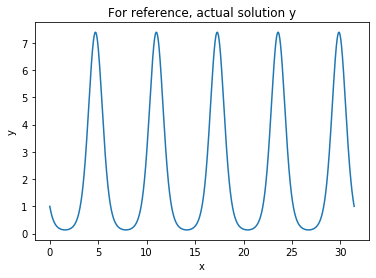

In [15]:
#reference plot
x_ref = np.linspace(0, 10*np.pi, 10000)
y_ref = np.exp(-2* np.sin(x_ref))

plt.plot(x_ref, y_ref)
plt.xlabel('x')
plt.ylabel('y')
plt.title("For reference, actual solution y")
plt.show()

For h=0.01, average y-value: 1.9101617792186754
For h=0.05, average y-value: 1.0178220080606892
For h=0.10, average y-value: 0.5377260346485454
For h=0.15, average y-value: 0.3197819117220568
For h=0.20, average y-value: 0.20447268245849218
For h=0.25, average y-value: 0.13579747480359125
For h=0.30, average y-value: 0.09125639188830169
For h=0.35, average y-value: 0.06084942690521079
For h=0.40, average y-value: 0.039498449970983056
For h=0.45, average y-value: 0.02501571846359043
For h=0.50, average y-value: 0.015873015873015872
For h=0.55, average y-value: 0.011934672322145672
For h=0.60, average y-value: 0.013523407568370874
For h=0.65, average y-value: 0.02096900039843341
For h=0.70, average y-value: 0.030886059308825094
For h=0.75, average y-value: 0.04591315686238471
For h=0.80, average y-value: 0.07611538792962044
For h=0.85, average y-value: 0.11852150043873337
For h=0.90, average y-value: 0.2769182873506145
For h=0.95, average y-value: 0.8205179594518478
For h=1.00, average y

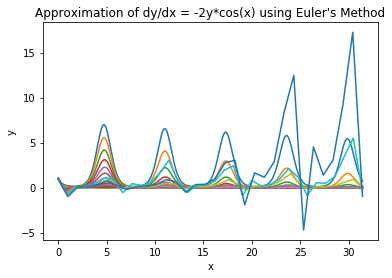

In [16]:
h_values = np.arange(0, 1.05, 0.05)
h_values[0] = 0.01
y_avg_error = np.zeros(len(h_values))
y_local_error = np.zeros(len(h_values))


for i in range(len(h_values)):
    y_avg_error[i], y_local_error[i] = euler(h_values[i])
    
    
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")
plt.show()

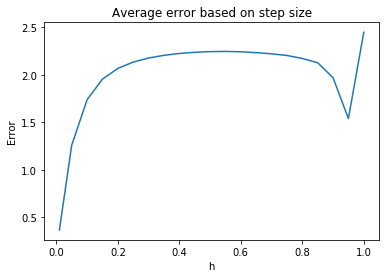

In [17]:
plt.plot(h_values, y_avg_error)
plt.xlabel('h')
plt.ylabel('Error')
plt.title("Average error based on step size")
plt.show()

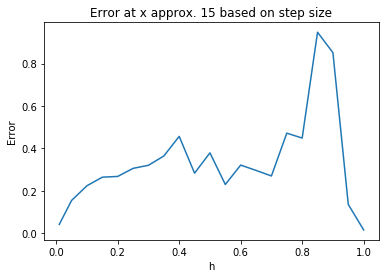

In [18]:
plt.plot(h_values, y_local_error)
plt.xlabel('h')
plt.ylabel('Error')
plt.title("Error at x approx. 15 based on step size")
plt.show()

Write-up:
As we increase the step-size h, we see that the resultant plots slowly lose the size of each "bump" until it eventually skyrockets back up and overshoots. The reasoning for this is that the higher step-size causes the method to miss the top of each bump, increasing the amount shaved off each time. Eventually, the step size reaches a point where it does hit the bump but from a much lower point than it should, causing it to think the derivative is higher at that point than it really is. We can see this variance in the absolute error graph, as well. x=15 is a much broader point of the graph than these peaks, which is why its error graph has more variance.

# Addendum

In [19]:
# dy/dx = -2y * cosx
# dy/dx = lambda * y
# lambda = -2cosx

# | 1 + lambda * h | <= 1
# -1 <= lambda * h <= 1
# 0 <= lambda * h <= 2 
# 0 <= h <= 2/lambda

# h != 0

# h <= 2/(-2cosx)
# h <= -1/(cosx)

# -1 <= cosx <= 1

# h <= 1


# For the solution to be stable, the step size must be less than or equal to 1